In [6]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/wknn_experiment_2'

errors_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

print(config)

{'max_wknn_k': 3, 'rf_param': 'sinr', 'operator_choice': [1, 10, 50, 88], 'n_runs': 2, 'campaigns': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'runtime': 111.53474116325378}


In [7]:
errors_df[errors_df['wknn_k'] == 2].groupby(['rf_param'])['errors'].mean()


rf_param
rsrp    3.193989
rsrq    2.990987
rssi    3.435521
sinr    3.025189
Name: errors, dtype: float64

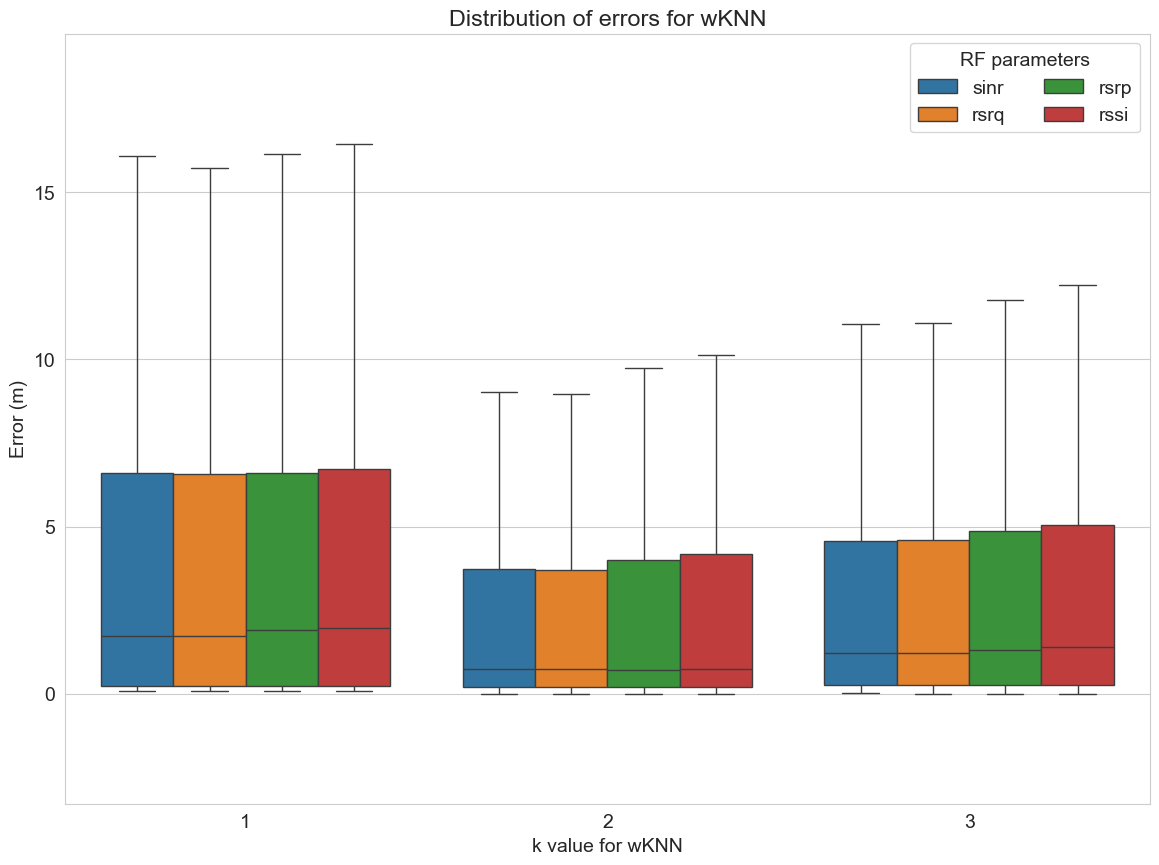

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

data_df = errors_df[errors_df['wknn_k'] < 11]

plt.rcParams['font.size'] = 14
plt.figure(figsize=(14, 10))

sns.boxplot(data=data_df, x='wknn_k', y='errors', hue='rf_param', showfliers=False)

plt.xlabel('k value for wKNN')
plt.ylabel('Error (m)')
plt.title('Distribution of errors for wKNN')

plt.legend(title='RF parameters', loc='upper right', ncol=2)
plt.margins(y=0.2)
plt.show()



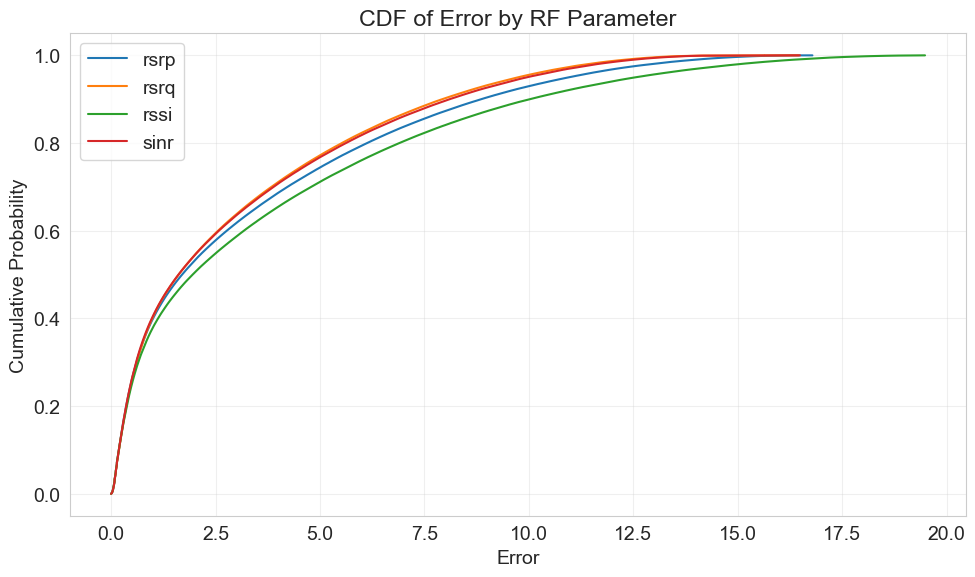

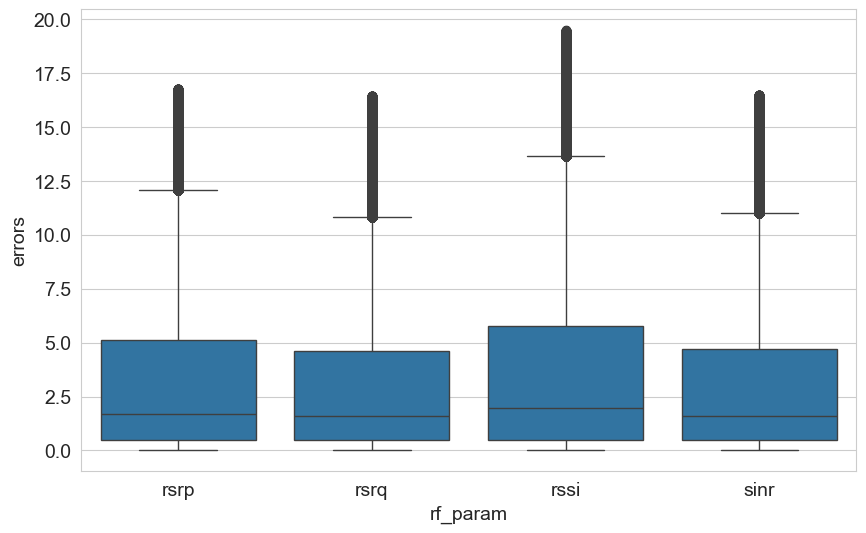

In [26]:
def remove_outliers_iqr(df, column, k=1.5):
    result_df = pd.DataFrame()

    # Group by both RF parameter and WKNN k value
    for (rf_param, wknn_k), group in df.groupby(['rf_param', 'wknn_k']):
        q1 = group[column].quantile(0.25)
        q3 = group[column].quantile(0.75)
        iqr = q3 - q1

        # Define bounds
        lower_bound = q1 - k * iqr
        upper_bound = q3 + k * iqr

        # Filter outliers
        filtered_group = group[(group[column] >= lower_bound) &
                               (group[column] <= upper_bound)]

        result_df = pd.concat([result_df, filtered_group])

    return result_df


data_df = errors_df[errors_df['wknn_k'] == 2]
data_df = remove_outliers_iqr(errors_df, 'errors')
# make cdf
import numpy as np

grouped = data_df.groupby('rf_param')

# Create a figure
plt.figure(figsize=(10, 6))

# Plot CDF for each RF parameter
for name, group in grouped:
    # Sort the error values
    sorted_errors = np.sort(group['errors'].values)
    # Calculate the CDF (y-axis values from 0 to 1)
    y_values = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

    # Plot the CDF line for this RF parameter
    plt.plot(sorted_errors, y_values, label=name)

# Add labels and title
plt.xlabel('Error')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Error by RF Parameter')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

plt.figure(figsize=(10, 6))

sns.boxplot(data_df, x='rf_param', y='errors', showfliers=True)

plt.show()

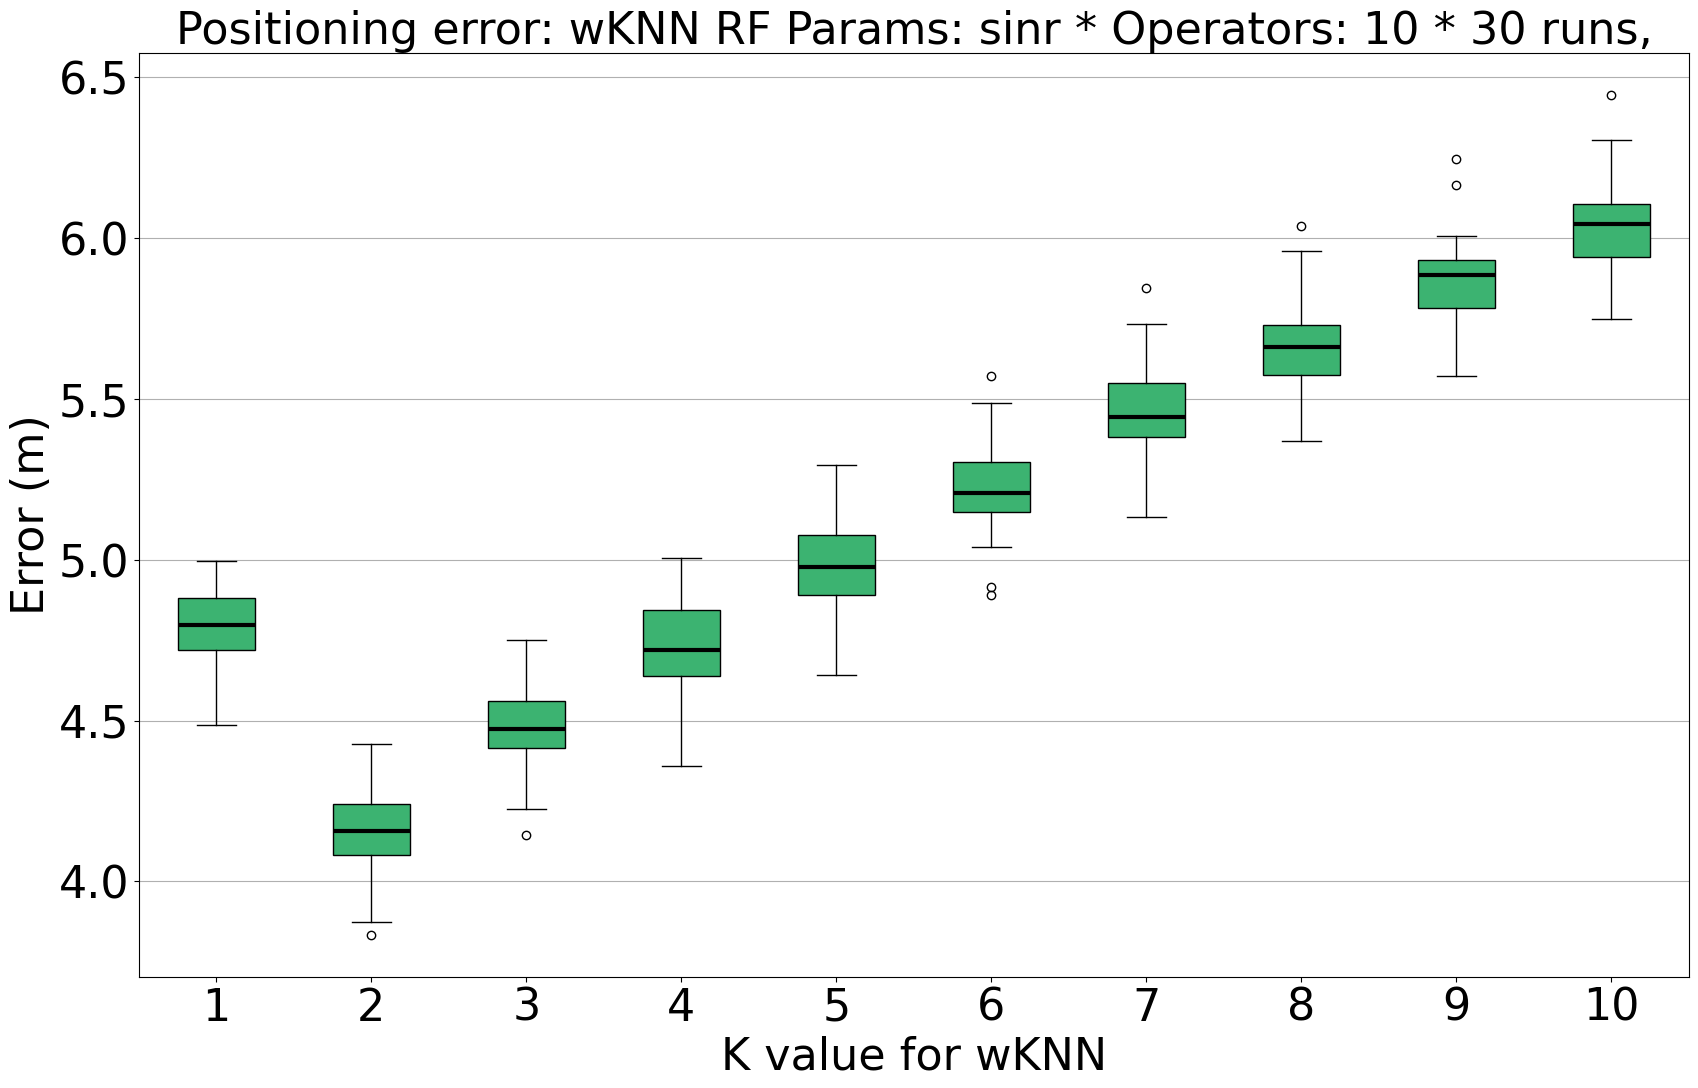

In [11]:
from scripts.utils import operators_to_str
from scripts.plotting import make_boxplot

param_str = f'RF Params: {config["rf_param"]}'
operator_str = f'Operators: {operators_to_str(config["operator_choice"])}'

title_string = f'wKNN {param_str} * {operator_str} * {config["n_runs"]} runs,'
make_boxplot(
    df=errors_df,
    title=f'Positioning error: {title_string}',
    x_label='K value for wKNN',
    y_label='Error (m)',
    color='mediumseagreen',
)
